<a href="https://colab.research.google.com/github/jnaneshpm11-debug/jnan/blob/main/Random%20forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
from google.colab import files
uploaded = files.upload()

Saving Boston.csv to Boston.csv


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv('Boston.csv')
print(df.head())

   Unnamed: 0     crim    zn  indus  chas    nox     rm   age     dis  rad  \
0           1  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1   
1           2  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2   
2           3  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2   
3           4  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3   
4           5  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3   

   tax  ptratio   black  lstat  medv  
0  296     15.3  396.90   4.98  24.0  
1  242     17.8  396.90   9.14  21.6  
2  242     17.8  392.83   4.03  34.7  
3  222     18.7  394.63   2.94  33.4  
4  222     18.7  396.90   5.33  36.2  


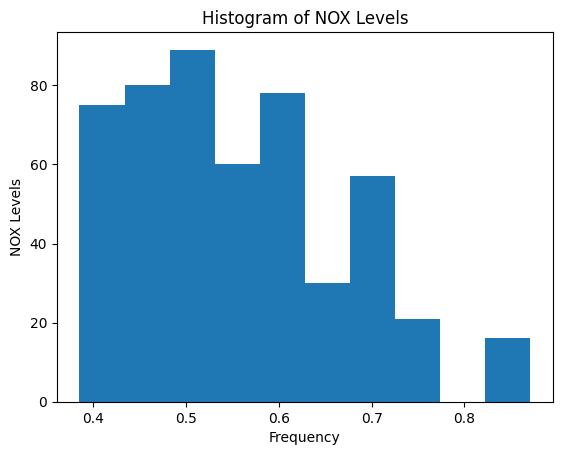

In [11]:
plt.hist(df['nox'], bins=10)
plt.xlabel('Frequency')
plt.ylabel('NOX Levels')
plt.title('Histogram of NOX Levels')
plt.show()

In [13]:
dataset = pd.read_csv('Boston.csv')
print(dataset.head())

   Unnamed: 0     crim    zn  indus  chas    nox     rm   age     dis  rad  \
0           1  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1   
1           2  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2   
2           3  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2   
3           4  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3   
4           5  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3   

   tax  ptratio   black  lstat  medv  
0  296     15.3  396.90   4.98  24.0  
1  242     17.8  396.90   9.14  21.6  
2  242     17.8  392.83   4.03  34.7  
3  222     18.7  394.63   2.94  33.4  
4  222     18.7  396.90   5.33  36.2  


In [14]:
x = pd.DataFrame(dataset.iloc[:, :-1])
y = pd.DataFrame(dataset.iloc[:, -1])
print("Input variables:")
print(x.head())
print("\nTarget variable:")
print(y.head())

Input variables:
   Unnamed: 0     crim    zn  indus  chas    nox     rm   age     dis  rad  \
0           1  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1   
1           2  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2   
2           3  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2   
3           4  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3   
4           5  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3   

   tax  ptratio   black  lstat  
0  296     15.3  396.90   4.98  
1  242     17.8  396.90   9.14  
2  242     17.8  392.83   4.03  
3  222     18.7  394.63   2.94  
4  222     18.7  396.90   5.33  

Target variable:
   medv
0  24.0
1  21.6
2  34.7
3  33.4
4  36.2


In [15]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)
print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

Training data: (404, 14)
Testing data: (102, 14)


In [16]:
from sklearn.ensemble import RandomForestRegressor
regressor = RandomForestRegressor(
    n_estimators=20,
    random_state=0
)

In [17]:
regressor.fit(x_train, y_train.values.ravel())

RandomForestRegressor(n_estimators=20, random_state=0)

In [18]:
y_pred = regressor.predict(x_test)
print("Predicted values:")
print(y_pred)

Predicted values:
[23.245 32.21  17.885 24.    15.995 21.195 20.365 16.17  21.895 20.185
 19.95  19.685  8.77  21.09  20.37  25.63  18.855  8.11  43.035 13.68
 25.155 23.87  14.295 22.235 14.24  14.55  21.105 13.5   19.27  21.445
 19.33  23.31  34.76  20.145 14.99  15.635 35.225 19.145 20.385 24.42
 18.16  30.125 43.13  19.47  21.865 13.735 14.605 24.295 18.615 27.83
 20.6   34.925 16.48  26.795 44.5   22.31  15.705 32.99  21.67  20.43
 25.89  34.675 31.16  19.6   26.62  16.815 13.98  23.3   28.    14.1
 20.5   25.02  10.86  21.775 22.27   6.71  20.045 43.395 11.475 12.755
 21.885 12.895 20.715  8.89  20.825 27.195 15.355 23.03  24.355 18.305
 21.85   8.24  19.56  18.435 22.67  19.295 36.23  14.025 11.855 14.405
 20.57  23.53 ]


In [19]:
from sklearn import metrics
mae = metrics.mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 2.1278921568627447


In [20]:
from sklearn import metrics
mae = metrics.mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 2.1278921568627447


In [21]:
mse = metrics.mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 11.337336519607843


In [22]:
rmse = np.sqrt(metrics.mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 3.3670961553849104


In [23]:
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)

Mean Absolute Error: 2.1278921568627447
Mean Squared Error: 11.337336519607843
Root Mean Squared Error: 3.3670961553849104
